# Статистические Критерии. Проверка Гипотез

**Исполнители (ФИО):** Липунцов Антон Юрьевич

---

Здравствуйте! В этом практикуме вы познакомитесь со статистическими критериями для проверки гипотез

**Полезные ссылки:**



Критерий определяется гипотезой $H_0$ - утверждение, которое мы хотим проверить, и альтернативой $H_1$, то что мы принимаем в случае опровержения гипотезы. Гипотеза $H_0$ выбирается таким образом, чтобы нам было критично ее неверно отвергать, потому, по-умолчанию мы считаем, что она всегда выполнена. Тут возникают две возможные ошибки:
1. Если $H_0$ верна, а мы ее опровергли - **ошибка первого рода ($\alpha$)**  
2. Если $H_0$ не верна, а мы ее приняли - **ошибка второго рода ($\beta$)**

Ошибка первого рода для нас критична, поэтому мы строим критерий так, чтобы ее минимизировать, при этом ошибку второго рода минимизировать не всегда получается и мы принимаем ее такой какая она есть:
1. Максимально возможная ошибка первого рода для критерия это его уровень значимости: $\alpha$
2. Ошибка второго рода позволяет оценить мощность критерия: $1 - \beta$. Это то, насколько хорошо критерий различает выборки из гипотезы и альтернативы  

Чтобы построить критерий, нужно выбрать статистику $T(X)$ и задать критическое множество $D -$ множество, попав в которое мы отвергаем $H_0$. Статистику выбирают таким образом, чтобы на выборках из гипотезы она была меньше либо больше, чем на выборках из альтернативы, тогда критическое множество можно задать как: $D = \{T(X) > C\}$ или $D = \{T(X) < C\}$, где $C -$ критическое значение, а $T -$ статистика критерия

## Задача 1

Будем работать с данными вида: $X_1, ... X_n \sim R[\theta, \theta + 2], n = 20$. Рассмотрим гипотезу и две альтернативы:
1. Гипотеза  $H_0: \theta = 0$  
Альтернатива $H_1: \theta = 0.1$
2. Гипотеза  $H_0: \theta = 0$  
Альтернатива $H_2: \theta = -0.1$

Используя одну из статистик $X_{(1)}, X_{(n)}$ постройте критические множества $D_1, D_2$ для альтернатив $H_1, H_2$

**Вопрос:** Как выглядит ваше критическое множества $D_1$ и $D_2$?

$H_1: \theta = 0.1$  
$D_1$= {$X_{(n)}>C$} - максимум больше 2  

$H_2: \theta = -0.1$  
$D_2$= {$X_{(1)}<C$} - минимум меньше 0   

Постройте графики зависимости ошибки первого рода от критического значения $\alpha(C)$ для критериев с альтернативой $H_1$ и $H_2$. Для этого:
1. Возьмите набор значений $C$
2. Для каждого $C$ сгенерируйте 100 выборок из гипотезы $H_0$
3. Посчитайте долю выборок, попавших в критическое множество $D_1$, $D_2$

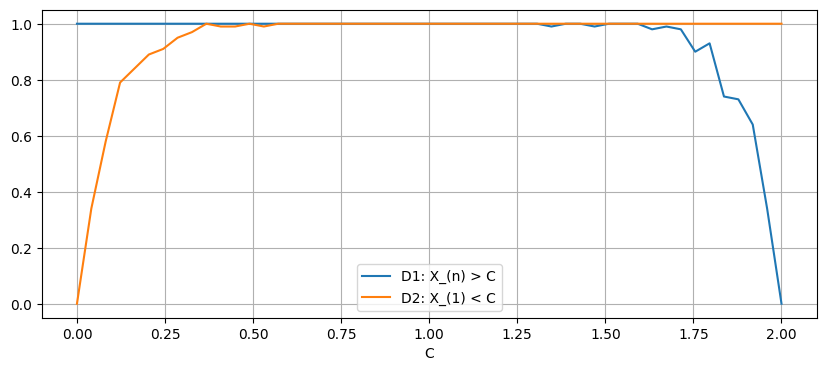

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

n = 20
n_sim = 100
C_vals = np.linspace(0, 2, 50)

alpha1 = []
for C in C_vals:
    reject = 0
    for _ in range(n_sim):
        sample = np.random.uniform(0, 2, n)
        if sample.max() > C:
            reject += 1
    alpha1.append(reject / n_sim)

alpha2 = []
for C in C_vals:
    reject = 0
    for _ in range(n_sim):
        sample = np.random.uniform(0, 2, n)
        if sample.min() < C:
            reject += 1
    alpha2.append(reject / n_sim)

plt.figure(figsize=(10,4))
plt.plot(C_vals, alpha1, label='D1: X_(n) > C')
plt.plot(C_vals, alpha2, label='D2: X_(1) < C')
plt.xlabel('C')
plt.legend()
plt.grid(True)
plt.show()

Постройте графики зависимости ошибки второго рода от критического значения $\beta(C)$ для критериев с альтернативой $H_1$ и $H_2$. Для этого:
1. Возьмите набор значений $C$
2. Для каждого $C$ сгенерируйте 100 выборок из альтернативы $H_1$
3. Посчитайте долю выборок, не попавших в критическое множество $D_1$
4. Проделайте шаги 2-3 для альтернативы $H_2$ и множества $D_{2}$

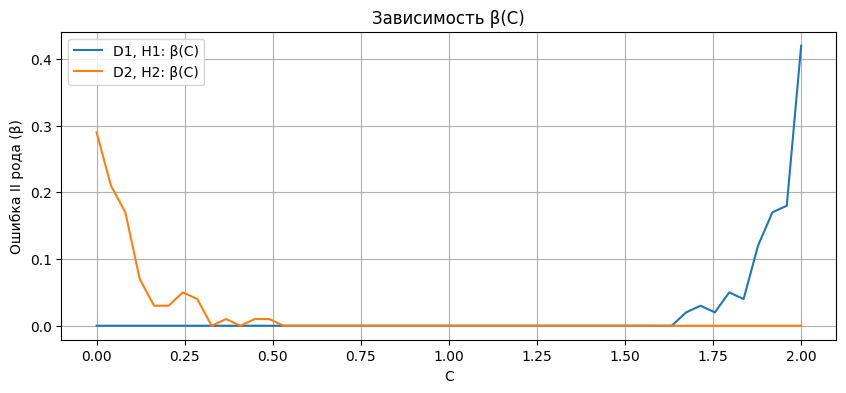

In [ ]:
beta1 = []
for C in C_vals:
    accept = 0
    for _ in range(n_sim):
        sample = np.random.uniform(0.1, 2.1, n)
        if sample.max() <= C:
            accept += 1
    beta1.append(accept / n_sim)

beta2 = []
for C in C_vals:
    accept = 0
    for _ in range(n_sim):
        sample = np.random.uniform(-0.1, 1.9, n)
        if sample.min() >= C:
            accept += 1
    beta2.append(accept / n_sim)

plt.figure(figsize=(10,4))
plt.plot(C_vals, beta1, label='D1, H1: β(C)')
plt.plot(C_vals, beta2, label='D2, H2: β(C)')
plt.xlabel('C')
plt.ylabel('Ошибка II рода (β)')
plt.legend()
plt.grid(True)
plt.title('Зависимость β(C)')
plt.show()

**Вопрос:** Какой порог $C$ вы бы выбрали? Можно ли одновременно минимизировать обе ошибки? Какие ошибки I и II рода у вас получились при выбранном пороге? Обоснуйте ответ

Для $D_1: C = 1,85$  
Для $D_2: C = 0,15$    
С = 0.5 для D1 и С = 1.5 для D2. Нельзя одновременно минимизировать обе ошибки – уменьшение одной ведёт к увеличению другой.  
Для D1 = {X(1) > C}: $α(C) = (1-c/n)^n, β(C) = 1-((2,1 - C)/2)^n$  
Для D2 = {X(n) < C}: $α(C) = (C/n)^n, β(C) = 1-((C+0,1)/2)^n$

## Задача 2

Чтобы найти критическое значение $C$ при заданном уровне значимости $\alpha$, необходимо вычислить функцию распределения статистики критерия при гипотезе $F_{T, H_0}$. Тогда:
1. Для критического множества вида $\{T(X) < C\}$ нам нужно найти такое $C$ при котором $F_{T, H_0}(C) = P(T(X_{H_0}) < C) = \alpha\%$, где $X_{H_0} -$ выборка из гипотезы. Таким образом $C = F^{-1}_{T, H_0}(\alpha)$
2. Для критического множества вида $\{T(X) > C\}$ нам нужно найти такое $C$ при котором $P(T(X_{H_0}) > C) = \alpha\%$, где $X_{H_0} -$ выборка из гипотезы. Это равносильно поиску $C$, при котором $F_{T, H_0}(C) = P(T(X_{H_0}) \leq C) = 1 - \alpha\%$. Таким образом $C = F^{-1}_{T, H_0}(1 - \alpha)$

Зафиксируйте уровень значимости $\alpha = 5\%$, используя функцию распределения статистики при гипотезе, вычислите критические значения для критического множеств $D_1$

In [ ]:
alpha = 0.05
n = 20

C1 = 2 * (1 - alpha) ** (1/n)
C2 = 2 * (1 - (1 - alpha) ** (1/n))

print(f"D1: C = {C1}")
print(f"D2: C = {C2}")

D1: C = 1.9948772424469394
D2: C = 0.005122757553060575


Зафиксируйте уровень значимости $\alpha = 5\%$, используя функцию распределения статистики при гипотезе, вычислите критические значения для критического множеств $D_2$

In [ ]:
# Your code here

Проверьте работу ваших критериев на выборках из альтернативы, для этого постройте графики зависимости мощности критерия $1 - \beta$ от размера выборки $n$

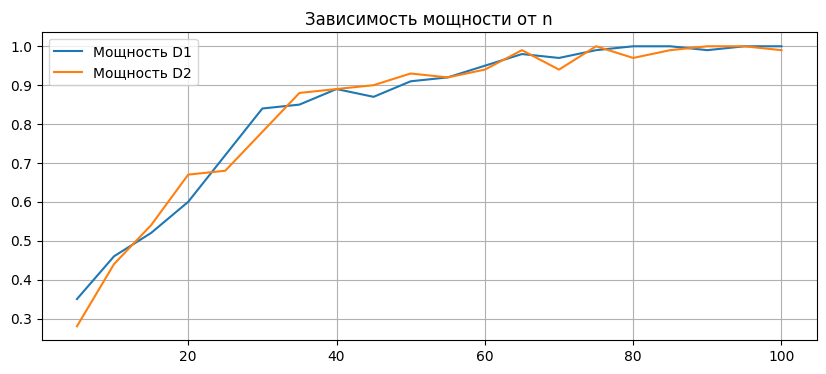

In [ ]:
n_vals = range(5, 101, 5)
power1 = []
power2 = []

for n in n_vals:
    C1n = 2 * (1 - alpha) ** (1/n)
    C2n = 2 * (1 - (1 - alpha) ** (1/n))

    reject1 = 0
    for _ in range(100):
        sample = np.random.uniform(0.1, 2.1, n)
        if sample.max() > C1n:
            reject1 += 1
    power1.append(reject1 / 100)

    reject2 = 0
    for _ in range(100):
        sample = np.random.uniform(-0.1, 1.9, n)
        if sample.min() < C2n:
            reject2 += 1
    power2.append(reject2 / 100)

plt.figure(figsize=(10,4))
plt.plot(n_vals, power1, label='Мощность D1')
plt.plot(n_vals, power2, label='Мощность D2')
plt.legend()
plt.grid(True)
plt.title('Зависимость мощности от n')
plt.show()

**Вопрос:** Какие получились критические значения для критических множеств $D_1$, $D_2$? Как меняется мощность критерия с ростом размера выборки?

D1 (X(1) > C): C = 2 * (1-0.05^(1/20))≈ 0.2786
D2 (X(n) < C): C = 2*0.05^1/20 ≈ 1.7214

  Мощность 1-β растёт с увеличением n, т.к. ростом n выборочные экстремумы X(1) и X(n) сходятся по вероятности к истинным θ и θ+2

## Задача 3

Для более удобной работы с результатами критерия используют *фактический уровень значимости* - p-value:
1. Для критического множества вида $\{T(X) < C\}$, p-value $= F_{T, H_0}(T)$
2. Для критического множества вида $\{T(X) > C\}$, p-value $= 1 - F_{T, H_0}(T)$

Он обладает полезным свойством: при гипотезе p-value $\sim R[0, 1]$, а при альтернативе его значения будут преимущественно около нуля (что следует из того, как мы выбирали $C$). Отсюда принцип пользования им следующий:
1. Выбираем уровень значимости, например 5%
2. Считаем p-value
3. Смотрим на его значение: если оно больше выбранного уровня значимости (0.05), то принимаем гипотезу, в противном случае - отвергаем, притом чем дальше значение от границы, тем более мы уверены в своем решении

Постройте гистограммы p-value при гипотезе для ваших критериев. Для этого сгенерируйте 100 выборок из гипотезы и вычислите по ним p-value для обоих критериев

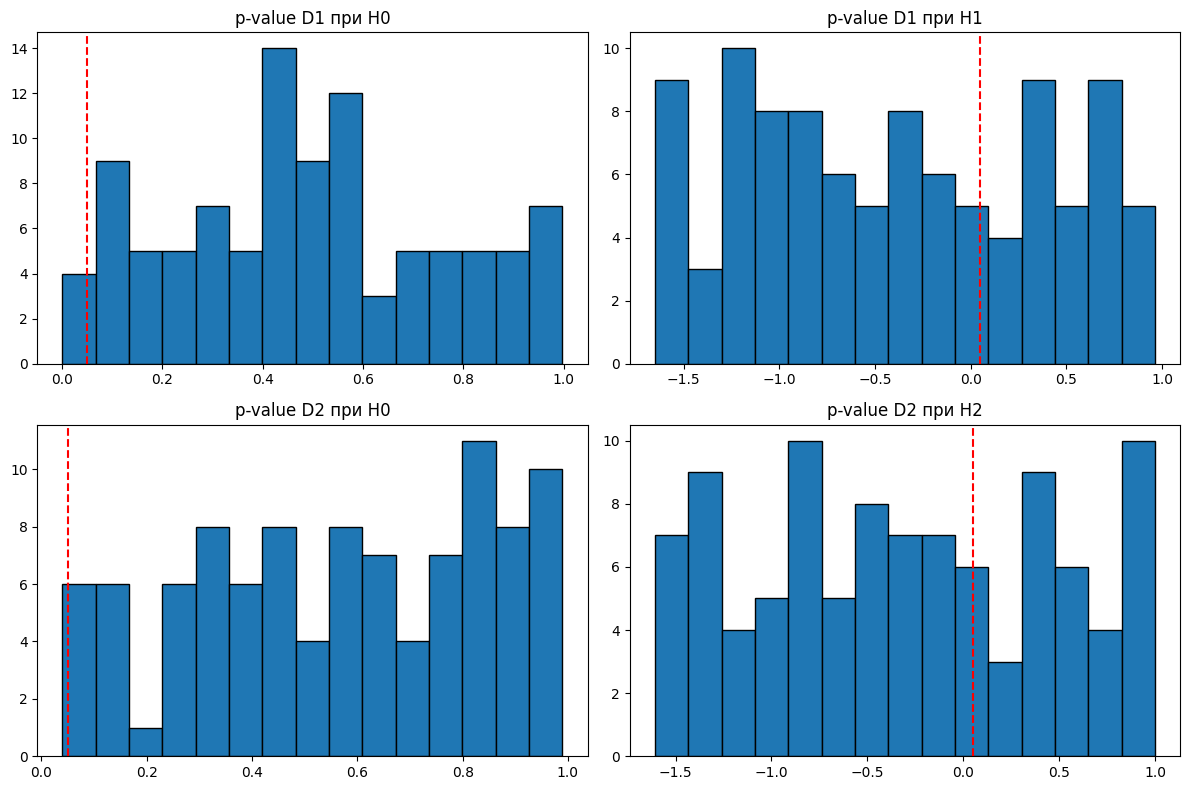

In [ ]:
def pvalue1(x_max, n):
    return 1 - (x_max / 2) ** n

def pvalue2(x_min, n):
    return 1 - (1 - x_min / 2) ** n

n = 20
pvals1_H0 = []
pvals2_H0 = []
for _ in range(100):
    sample = np.random.uniform(0, 2, n)
    pvals1_H0.append(pvalue1(sample.max(), n))
    pvals2_H0.append(pvalue2(sample.min(), n))

pvals1_H1 = []
for _ in range(100):
    sample = np.random.uniform(0.1, 2.1, n)
    pvals1_H1.append(pvalue1(sample.max(), n))

pvals2_H2 = []
for _ in range(100):
    sample = np.random.uniform(-0.1, 1.9, n)
    pvals2_H2.append(pvalue2(sample.min(), n))

fig, axes = plt.subplots(2, 2, figsize=(12,8))
axes[0,0].hist(pvals1_H0, bins=15, edgecolor='k')
axes[0,0].axvline(x=alpha, color='red', linestyle='--', label=f'α = {alpha}')
axes[0,0].set_title('p-value D1 при H0')
axes[0,1].hist(pvals1_H1, bins=15, edgecolor='k')
axes[0,1].axvline(x=alpha, color='red', linestyle='--', label=f'α = {alpha}')
axes[0,1].set_title('p-value D1 при H1')
axes[1,0].hist(pvals2_H0, bins=15, edgecolor='k')
axes[1,0].axvline(x=alpha, color='red', linestyle='--', label=f'α = {alpha}')
axes[1,0].set_title('p-value D2 при H0')
axes[1,1].hist(pvals2_H2, bins=15, edgecolor='k')
axes[1,1].set_title('p-value D2 при H2')
axes[1,1].axvline(x=alpha, color='red', linestyle='--', label=f'α = {alpha}')
plt.tight_layout()
plt.show()

Постройте гистограммы p-value для выборок из альтернативы для ваших критериев

**Вопрос:** Как распределен p-value с в случае гипотезы и альтернативы в ваших критериях? Соотносятся ли эти распределения с ожидаемыми?

$p_1​=P_{H0}​​(T1​≥t) = (\frac{2-X_{(1)}}{2}​)^n$  
$p_2 = P_{H0}(T2​≤t)=(\frac{t}{2}​)^n = (\frac{X_{(n)}}{2})^n$  
p-value $\sim R[0, 1]$

Для сравнения работы нескольких критериев удобно строить график $(\text{p-value}_{(i)}, \frac{i}{n})$ (по сути это ЭФР для p-value или же qqpot, потому при гипотезе данные должны ложится на диагональ). Постройте два графика $(\text{p-value}_{(i)}, \frac{i}{n})$, на первом сравните результаты работы ваших критериев при гипотезе, а на втором $-$ при альтернативе. Попробуйте разные размеры выборок

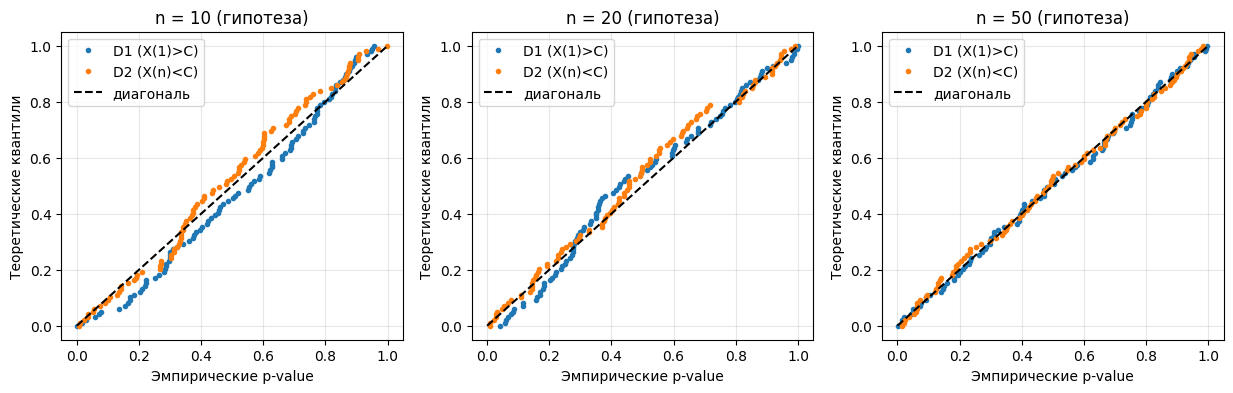

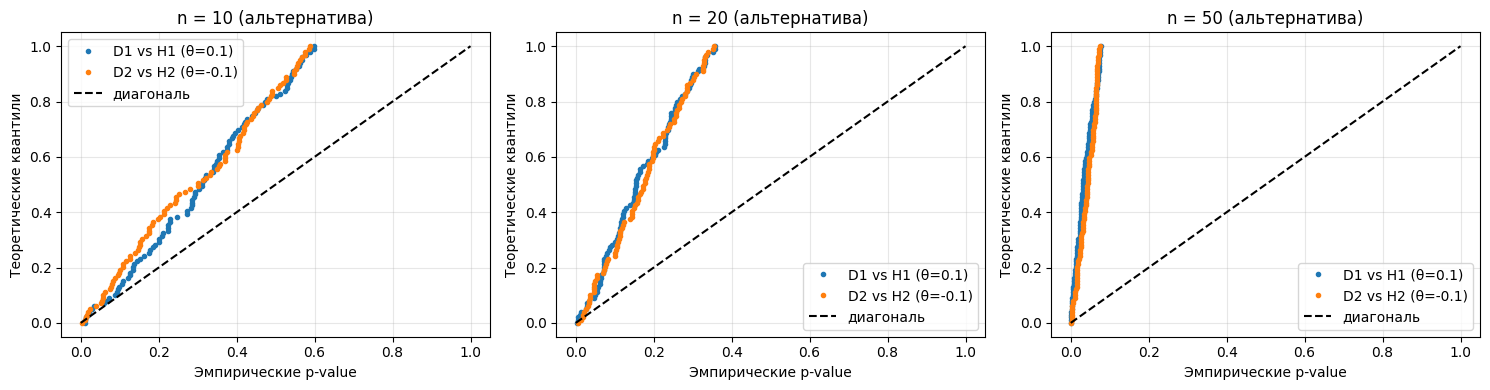

In [ ]:
np.random.seed(42)

alpha = 0.05
n_sims = 100
n_vals = [10, 20, 50]

fig1, axes1 = plt.subplots(1, 3, figsize=(15, 4))
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 4))

for i in range(len(n_vals)):
    n = n_vals[i]

    p1_H0 = []
    p2_H0 = []
    for _ in range(n_sims):
        sample = np.random.uniform(0, 2, n)
        X1 = np.min(sample)
        Xn = np.max(sample)
        p1_H0.append((1 - X1/2) ** n)
        p2_H0.append((Xn / 2) ** n)

    p1_H1 = []
    p2_H2 = []
    for _ in range(n_sims):
        sample1 = np.random.uniform(0.1, 2.1, n)
        p1_H1.append((1 - np.min(sample1)/2) ** n)

        sample2 = np.random.uniform(-0.1, 1.9, n)
        p2_H2.append((np.max(sample2) / 2) ** n)

    p1_H0_sorted = np.sort(p1_H0)
    p2_H0_sorted = np.sort(p2_H0)
    p1_H1_sorted = np.sort(p1_H1)
    p2_H2_sorted = np.sort(p2_H2)

    expected = np.linspace(0, 1, n_sims)

    axes1[i].plot(p1_H0_sorted, expected, 'o', markersize=3, label='D1 (X(1)>C)')
    axes1[i].plot(p2_H0_sorted, expected, 'o', markersize=3, label='D2 (X(n)<C)')
    axes1[i].plot([0, 1], [0, 1], 'k--', label='диагональ')
    axes1[i].set_xlabel('Эмпирические p-value')
    axes1[i].set_ylabel('Теоретические квантили')
    axes1[i].set_title(f'n = {n} (гипотеза)')
    axes1[i].legend()
    axes1[i].grid(True, alpha=0.3)

    axes2[i].plot(p1_H1_sorted, expected, 'o', markersize=3, label='D1 vs H1 (θ=0.1)')
    axes2[i].plot(p2_H2_sorted, expected, 'o', markersize=3, label='D2 vs H2 (θ=-0.1)')
    axes2[i].plot([0, 1], [0, 1], 'k--', label='диагональ')
    axes2[i].set_xlabel('Эмпирические p-value')
    axes2[i].set_ylabel('Теоретические квантили')
    axes2[i].set_title(f'n = {n} (альтернатива)')
    axes2[i].legend()
    axes2[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Вопрос:** Какой критерий справился лучше? Как влияет размер выборки на результат работы ваших критериев?

С ростом n:

минимум и максимум становятся более информативными;  
различие между распределениями при H0 и H1
 (или H2
) усиливается;  
p-value всё чаще оказываются близки к нулю.

Оба критерия работают одинаково (симметрично).
При H0 оба ложатся на диагональ (p-value ~ R[0,1]).
При альтернативе оба показывают одинаковое отклонение от диагонали — точки лежат выше диагонали (p-value смещены к нулю). С ростом n способность критериев отличать гипотезу от альтернативы улучшается (мощность -> 1). При малых n различить сдвиг 0.1 практически невозможно.

## Задача 4

Ваш друг - нумизмат, который раздобыл несколько новых монет в свою коллекцию. Но у него есть сомнения об их подлинности. Он просит вас как статистика определить, какие из монет подлинные. Известно, что настоящие монеты делают симметричными.

Ваш друг подбросил каждую монету по 50 раз и собрал в датасет *coins.csv*. Постройте критерий для того чтобы ответить на вопрос: честная ли монета?

Задайте гипотезу и альтернативу, сконструируйте подходящую статистику и вычислите ее функцию распределения при гипотезе. Для проверки вашего предположения можно сгенерировать выборки из гипотезы, посчитать по ним статистику и проверить ее /распределение с теоретическим при помощи qqplot

In [ ]:
df = pd.read_csv('coins.csv', sep=',')
df.columns = ['Результат', 'Монета']

def binom_pvalue(k, n=50, p=0.5):
    if k / n < p:
        pval = 2 * stats.binom.cdf(k, n, p)
    else:
        pval = 2 * (1 - stats.binom.cdf(k-1, n, p))
    return min(pval, 1.0)

results = []
for coin in range(1, 6):
    data = df[df['Монета'] == coin]['Результат']
    k = data.sum()
    pval = binom_pvalue(k)
    results.append((coin, k, pval, pval < 0.05))

res_df = pd.DataFrame(results, columns=['Монета', 'Орлов', 'p-value', 'Отвергаем H0 (α=5%)'])
print(res_df)

   Монета  Орлов       p-value  Отвергаем H0 (α=5%)
0       1     15  6.600448e-03                 True
1       2     25  1.000000e+00                False
2       3     24  8.877248e-01                False
3       4     25  1.000000e+00                False
4       5     46  4.461782e-10                 True


Проверьте чувствительность критерия, для этого постройте гистограммы p-value на разных выборках не из гипотезы

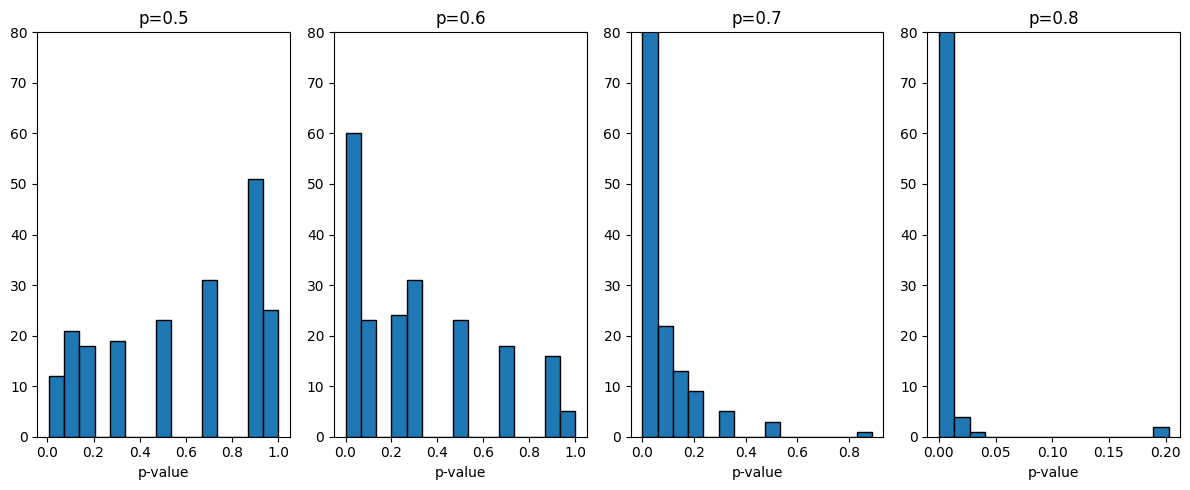

In [ ]:
n_flips = 50
n_sim = 200

p_vals = [0.5, 0.6, 0.7, 0.8]
pval_dist = {}

for p in p_vals:
    pvals = []
    for _ in range(n_sim):
        k = np.random.binomial(n_flips, p)
        pvals.append(binom_pvalue(k, n_flips))
    pval_dist[p] = pvals

plt.figure(figsize=(12,5))
for i, p in enumerate(p_vals):
    plt.subplot(1,4,i+1)
    plt.hist(pval_dist[p], bins=15, edgecolor='k')
    plt.title(f'p={p}')
    plt.xlabel('p-value')
    plt.ylim(0, 80)
plt.tight_layout()
plt.show()

Используйте ваш критерий, чтобы проверить монеты из файла *coins.csv*

**Вопрос:** Как выглядит ваш критерий? Какова его чувствительность? Какие монеты прошли проверку на подлинность?

Критерий:
Биномиальный тест.
Статистика: S — число орлов в 50 бросках
При H_0: S ~ Binomial(n=50, p=0.5)
Критическое множество: S <= 18 или S >= 32 при alpha=0.05
p-value =  2*min(P(S <= s), P(S >= s))

Честные монеты: 1, 2, 3, 4

Нечестные: 5